<h1 style="font-size:20px;"><strong>
HANDSON MIDTERMS : Chicago Crimes year 2024 and 2025 Data Analytics</strong></h1>

<p>Analyst: Imari Calado</p>

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
crimes = pd.read_csv('Chicago_Crimes.csv')
crimes

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


In [127]:
crimes.isnull().sum()

ID                        0
Case Number               0
Date                      0
Block                     0
IUCR                      0
Primary Type              0
Description               0
Location Description    857
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                      0
Community Area            3
FBI Code                  0
X Coordinate             90
Y Coordinate             90
Year                      0
Updated On                0
Latitude                 90
Longitude                90
Location                 90
dtype: int64

<h1 style="font-size:20px;"><strong>
Data Cleansing</strong></h1>

In [128]:
crimes['Location Description'] = crimes['Location Description'].fillna(crimes ['Location Description'].mode()[0])
crimes['X Coordinate'] = crimes['X Coordinate'].fillna(crimes ['X Coordinate'].mode()[0])
crimes['Y Coordinate'] = crimes['Y Coordinate'].fillna(crimes ['Y Coordinate'].mode()[0])
crimes['Latitude'] = crimes['Latitude'].fillna(crimes['Latitude'].mode()[0])
crimes['Location'] = crimes['Location'].fillna(crimes['Location'].mode()[0])
crimes['Longitude'] = crimes['Longitude'].fillna(crimes['Longitude'].mode()[0])



In [129]:
crimes.isnull().sum()


ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          3
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
dtype: int64

<h1 style="font-size:20px;"><strong>
Categorical Data Fields</strong></h1>

In [130]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    249123 non-null  int64  
 1   Case Number           249123 non-null  object 
 2   Date                  249123 non-null  object 
 3   Block                 249123 non-null  object 
 4   IUCR                  249123 non-null  object 
 5   Primary Type          249123 non-null  object 
 6   Description           249123 non-null  object 
 7   Location Description  249123 non-null  object 
 8   Arrest                249123 non-null  bool   
 9   Domestic              249123 non-null  bool   
 10  Beat                  249123 non-null  int64  
 11  District              249123 non-null  int64  
 12  Ward                  249123 non-null  int64  
 13  Community Area        249120 non-null  float64
 14  FBI Code              249123 non-null  object 
 15  

In [131]:
crimes['Case Number'] = crimes ['Case Number'].astype('category')
crimes['Date'] = crimes ['Date'].astype('category')
crimes['Block'] = crimes ['Block'].astype('category')
crimes['IUCR'] = crimes ['IUCR'].astype('category')
crimes['Primary Type'] = crimes ['Primary Type'].astype('category')
crimes['Description'] = crimes ['Description'].astype('category')
crimes['Location Description'] = crimes ['Location Description'].astype('category')
crimes['FBI Code'] = crimes ['FBI Code'].astype('category')
crimes['Updated On'] = crimes ['Updated On'].astype('category')
crimes['Location'] = crimes ['Location'].astype('category')



In [132]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   ID                    249123 non-null  int64   
 1   Case Number           249123 non-null  category
 2   Date                  249123 non-null  category
 3   Block                 249123 non-null  category
 4   IUCR                  249123 non-null  category
 5   Primary Type          249123 non-null  category
 6   Description           249123 non-null  category
 7   Location Description  249123 non-null  category
 8   Arrest                249123 non-null  bool    
 9   Domestic              249123 non-null  bool    
 10  Beat                  249123 non-null  int64   
 11  District              249123 non-null  int64   
 12  Ward                  249123 non-null  int64   
 13  Community Area        249120 non-null  float64 
 14  FBI Code              249123 non-nul

<h1 style="font-size:20px;"><strong>
Adjusting Data Types</strong></h1>

In [133]:
crimes['Date'] = crimes ['Date'].str.strip()

crimes['Date'] = crimes ['Date'].astype('str')

crimes['Date'] = crimes ['Date'].str.replace('/','-')

crimes['Date'] = pd.to_datetime(crimes['Date'], dayfirst = True,  errors='coerce')


In [134]:
crimes.dtypes

ID                               int64
Case Number                   category
Date                    datetime64[ns]
Block                         category
IUCR                          category
Primary Type                  category
Description                   category
Location Description          category
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         int64
Ward                             int64
Community Area                 float64
FBI Code                      category
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On                    category
Latitude                       float64
Longitude                      float64
Location                      category
dtype: object

<h1 style="font-size:20px;"><strong>
Extracting date information using pandas date time </h1>

In [135]:
crimes['Year'] = crimes['Date'].dt.year
crimes['Month'] = crimes['Date'].dt.month
crimes['Day'] = crimes['Date'].dt.day
crimes['DayOfWeek'] = crimes['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

In [136]:
crimes.isnull().sum()

ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          3
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
Month                   0
Day                     0
DayOfWeek               0
dtype: int64

<h1 style="font-size:20px;"><strong>
CHICAGO CRIMES INSIGHTS</h1>

<h1 style="font-size:20px;"><strong>
1. Common crime types</h1>

In [137]:
crimes['Primary Type'].value_counts()

Primary Type
THEFT                                59201
BATTERY                              44579
CRIMINAL DAMAGE                      27094
ASSAULT                              22615
MOTOR VEHICLE THEFT                  19604
OTHER OFFENSE                        16781
DECEPTIVE PRACTICE                   14991
BURGLARY                              8443
ROBBERY                               8200
WEAPONS VIOLATION                     7164
NARCOTICS                             6627
CRIMINAL TRESPASS                     5045
OFFENSE INVOLVING CHILDREN            1597
CRIMINAL SEXUAL ASSAULT               1573
SEX OFFENSE                           1210
PUBLIC PEACE VIOLATION                1006
INTERFERENCE WITH PUBLIC OFFICER       771
HOMICIDE                               553
STALKING                               520
ARSON                                  452
PROSTITUTION                           287
CONCEALED CARRY LICENSE VIOLATION      249
LIQUOR LAW VIOLATION                   19

<h1 style="font-size:12px;"><strong>
Insight 1.Theft is the most common crime in Chicago</h1>

<h2 style="font-size:12px;"><strong>
Insight 2. Public Indecency is the least common crime types in Chicago</h2>

<h1 style="font-size:20px;"><strong>
2. Crimes Trends by yeara</h1>

In [138]:
crimes.groupby('Year').size()


Year
2024    188918
2025     60205
dtype: int64

In [139]:
crimes.groupby('Year').size().pct_change() * 100


Year
2024          NaN
2025   -68.131676
dtype: float64

<h1 style="font-size:12px;"><strong>
Insight 3.Crime totals were highest in the year 2024</h1>

<h2 style="font-size:12px;"><strong>
Insight 4. Crime totals have generally decreased year over year</h2>

<h1 style="font-size:20px;"><strong>
3. Crimes by Time of Day</h1>

In [140]:
crimes['Hour'] = pd.to_datetime(crimes['Date']).dt.hour
crimes.groupby('Hour').size()


Hour
0     16752
1      8420
2      7504
3      6477
4      5227
5      4551
6      4744
7      6368
8      8576
9     10171
10    10543
11    11023
12    14247
13    11268
14    11936
15    13511
16    13288
17    13566
18    13286
19    12902
20    12460
21    11534
22    10936
23     9833
dtype: int64

<h1 style="font-size:12px;"><strong>
Insight 5.Crime peak around midday to early evening(12pm - 7pm</h1>

<h1 style="font-size:12px;"><strong>
Insight 6.Crime drop after midnight (4-6am)</h1>



<h1 style="font-size:20px;"><strong>
4. Crimes by Location</h1>

In [141]:
crimes['Location Description'].value_counts().head(5)


Location Description
STREET                66897
APARTMENT             47787
RESIDENCE             29776
SIDEWALK              13265
SMALL RETAIL STORE     9858
Name: count, dtype: int64

In [142]:
(crimes['Location Description'] == 'STREET').mean() * 100


np.float64(26.85300032514059)

<h1 style="font-size:12px;"><strong>
Insight 7.STREET is the most common crime location</h1>

<h1 style="font-size:12px;"><strong>
Insight 8.About 27% of all crimes occured on the streets </h1>



<h1 style="font-size:20px;"><strong>
5. Crimes by District</h1>

In [143]:
crimes.groupby('District').size().sort_values(ascending=False).head()

District
8     16691
12    15355
1     14409
6     14157
19    13640
dtype: int64

In [146]:
crimes.groupby('District').size().idxmin()

np.int64(31)

In [147]:
crimes.groupby('District').size().max() / len(crimes) * 100


np.float64(6.69990326063832)

<h1 style="font-size:12px;"><strong>
Insight 9.District 8 has one of the highest number of crime with the total of 16691</h1>

<h2 style="font-size:12px;"><strong>
Insight 10.District 31 has the lowest number of crimes </h2>

<h3 style="font-size:12px;"><strong>
Insight 11. the busiest district accounts for 7% of all times </h3>



<h1 style="font-size:20px;"><strong>
6. Variations in Arrest Frequency by Crime Type</h1>

In [148]:
arrests_by_type = crimes.groupby('Primary Type')['Arrest'].sum().sort_values(ascending=False)
arrests_by_type.head()


Primary Type
BATTERY              7647
NARCOTICS            6351
WEAPONS VIOLATION    4646
THEFT                4529
OTHER OFFENSE        3368
Name: Arrest, dtype: int64

<h1 style="font-size:12px;"><strong>
Insight 12.Battery leads all crime categories in total arrests, showing stronger law enforcement response or higher reporting clarity.</h1>

<h2 style="font-size:12px;"><strong>
Insight 13.Narcotics closely follows, indicating active policing and higher likelihood of on-scene arrests</h2>

<h3 style="font-size:12px;"><strong>
Insight 14. Weapons violations rank third, surpassing Theft, which drops to fourth despite being one of the most frequent crimes overall</h3>



<h1 style="font-size:20px;"><strong>
7. Ranking Years by Highest Concentration of Reported Crimes</h1>

In [149]:
year_counts = (
    crimes.groupby('Year')
      .size()
      .reset_index(name='Total Crimes')
      .sort_values(by='Total Crimes', ascending=False)
)
year_counts


,Year,Total Crimes
0,2024,188918
1,2025,60205


<h1 style="font-size:12px;"><strong>
Insight 15.In 2024, there were 188,918 reported crimes, which is higher than in 2025.</h1>

<h2 style="font-size:12px;"><strong>
Insight 16. In 2025 has 60,205 crimes, showing a big gap to the previous year</h2>


<h1 style="font-size:20px;"><strong>
8. Geographic Correlation Among Administrative Zones</h1>

In [150]:
geo_corr = crimes[['Beat', 'District', 'Ward', 'Community Area']].corr(method='pearson')
geo_corr


,Beat,District,Ward,Community Area
Beat,1.000000,0.999775,0.653445,-0.476538
District,0.999775,1.000000,0.654330,-0.476645
Ward,0.653445,0.654330,1.000000,-0.544430
Community Area,-0.476538,-0.476645,-0.544430,1.000000


<h1 style="font-size:12px;"><strong>
Insight 17.Beat and District have an almost perfect positive correlation</strong></h1>

<h2 style="font-size:12px;"><strong>
Insight 18.Community Area has a negative correlation with the other three fields</h2>


<h1 style="font-size:20px;"><strong>
9. Crime Types Most Linked to Domestic Incidents</h1>

In [151]:
domestic_by_type = (
    crimes.groupby('Primary Type')['Domestic']
      .agg(['sum', 'count'])
      .assign(Domestic_Rate=lambda x: x['sum'] / x['count'])
      .sort_values(by='Domestic_Rate', ascending=False)
)
domestic_by_type


,sum,count,Domestic_Rate
Primary Type,,,
OFFENSE INVOLVING CHILDREN,1219,1597,0.763306
BATTERY,23764,44579,0.533076
STALKING,248,520,0.476923
KIDNAPPING,39,105,0.371429
OTHER OFFENSE,5970,16781,0.355759
ASSAULT,6453,22615,0.285342
SEX OFFENSE,257,1210,0.212397
OBSCENITY,11,53,0.207547
CRIMINAL SEXUAL ASSAULT,309,1573,0.196440


<h1 style="font-size:12px;"><strong>
Insight 19.Offense involving children have the highest domestic rate with the total number of 76% </strong></h1>

<h2 style="font-size:12px;"><strong>
Insight 20.Crimes like Narcotics, Weapons Violations, Robbery, and Motor Vehicle Theft have extremely low domestic rates wnder 2%</h2>


<h1 style="font-size:30px;"><strong>
VISUALIZATION </h1>

<h1 style="font-size:20px;"><strong>
ARREST TRENDS </h1>

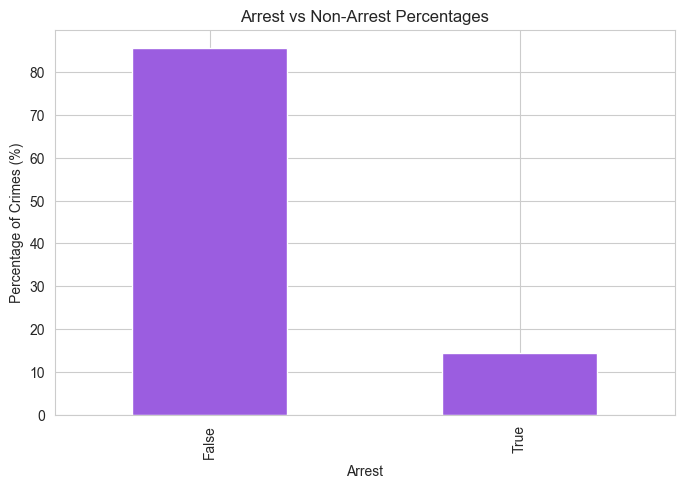

Arrest
False    85.548504
True     14.451496
Name: proportion, dtype: float64

In [152]:
import matplotlib.pyplot as plt

#arrest distribution
arrest_perc = crimes['Arrest'].value_counts(normalize=True) * 100


arrest_perc.plot(kind='bar', figsize=(8,5), color=['#9B5DE0'])
plt.title("Arrest vs Non-Arrest Percentages")
plt.xlabel("Arrest")
plt.ylabel("Percentage of Crimes (%)")
plt.show()

arrest_perc



<h1 style="font-size:12px;"><strong>
Insight 21. Only about 14% of crimes result in an arrest, indicating that most cases do not lead to immediate apprehension. </h1>

<h2 style="font-size:12px;"><strong>
Insight 22.Over 85% of cases have no arrest recorded, </h2>




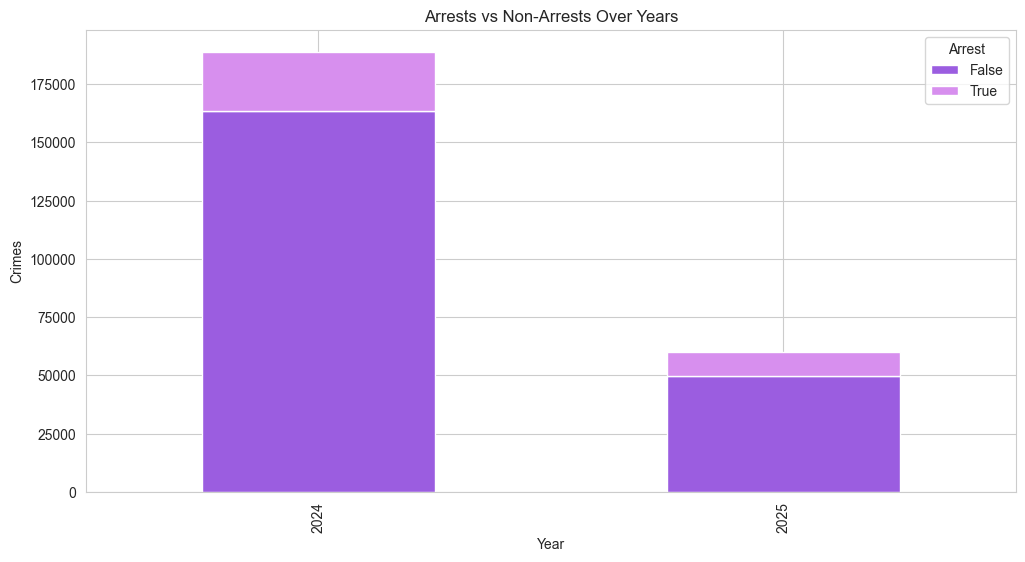

In [153]:
# arrests over time

crimes.groupby(['Year','Arrest']).size().unstack().plot(kind='bar',color=['#9B5DE0','#D78FEE' ],stacked=True, figsize=(12,6))
plt.title("Arrests vs Non-Arrests Over Years")
plt.ylabel("Crimes")
plt.show()

<h1 style="font-size:12px;"><strong>
Insight 23. Non-arrests consistently outnumber arrests in both 2024 and 2025 </h1>

<h1 style="font-size:12px;"><strong>
Insight 24 . total incidents drop sharply in 2025, but the proportion of arrests remains low compared to non-arrests.</h1>

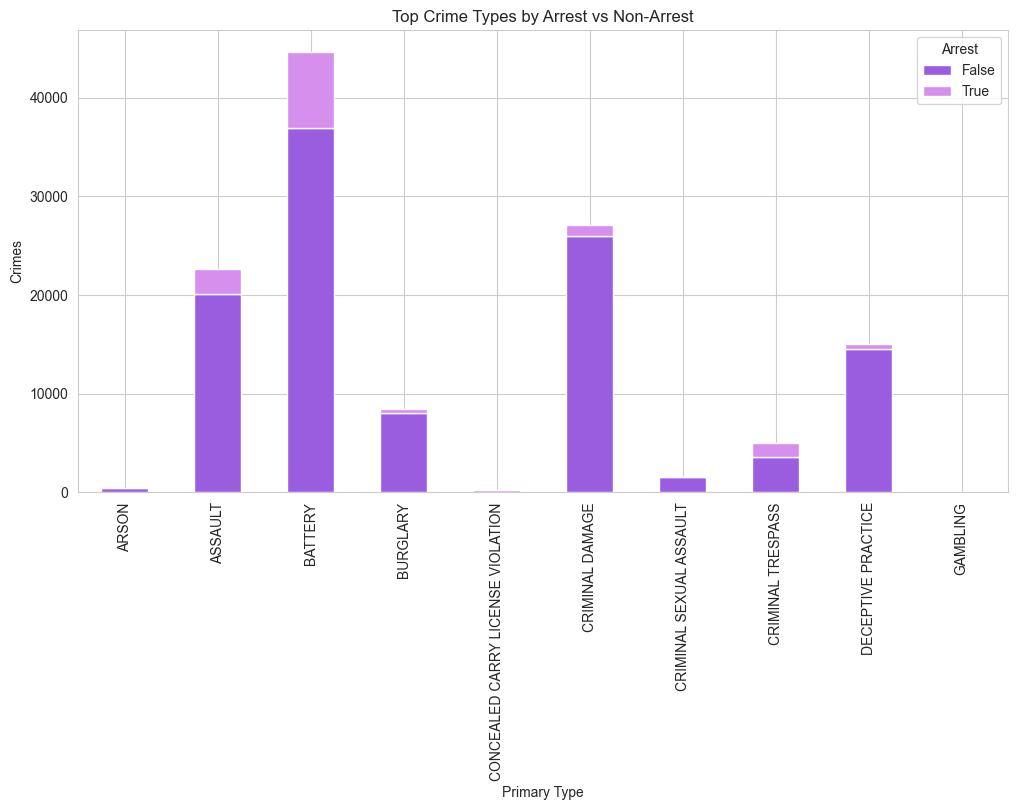

In [154]:
# arrest ratio by crime type
crimes.groupby(['Primary Type','Arrest']).size().unstack(fill_value=0).head(10).plot(kind='bar',color=['#9B5DE0','#D78FEE'], stacked=True, figsize=(12,6))
plt.title("Top Crime Types by Arrest vs Non-Arrest")
plt.ylabel("Crimes")
plt.show()

<h1 style="font-size:12px;"><strong>
Insight 25. Battery, assault, and criminal damage have the highest overall crime counts, but in each of these, non-arrests dominate over arrests.</h1>

<h1 style="font-size:12px;"><strong>
Insight 26. Among serious offenses like burglary and sexual assault, arrests make up only a small fraction of reported incidents, indicating enforcement challenges across multiple crime types.

<h1 style="font-size:20px;"><strong>
DOMESTIC CRIMES</h1>

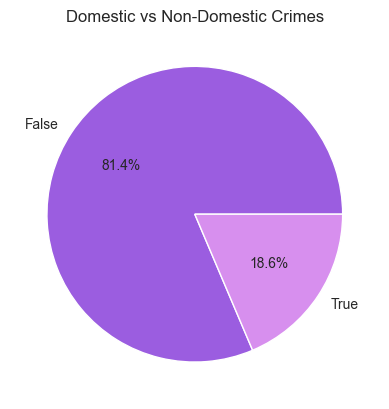

In [155]:
crimes['Domestic'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#9B5DE0','#D78FEE'])
plt.title("Domestic vs Non-Domestic Crimes")
plt.ylabel("")
plt.show()

<h1 style="font-size:12px;"><strong>
Insight 27. Non-Dmestic crimes make up the vast majority, accounting for over 80% of all reported incidents.</h1>

<h1 style="font-size:12px;"><strong>
Insight 28. Domestic crimes represent only around 18%, showing they form a smaller</h1>

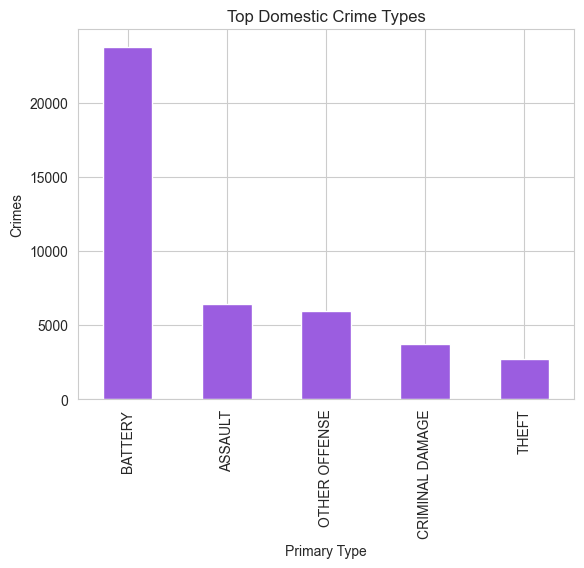

In [156]:
crimes[crimes['Domestic']==True]['Primary Type'].value_counts().head(5).plot(kind='bar', color='#9B5DE0')
plt.title("Top Domestic Crime Types")
plt.ylabel("Crimes")
plt.show()

<h1 style="font-size:12px;"><strong>
Insight 29. Battery is the dominant domestic crime, far ahead of all others in reported cases.</h1>

<h1 style="font-size:12px;"><strong>
Insight 30. Assault and Other Offense follow as the next most frequent domestic offenses</h1>

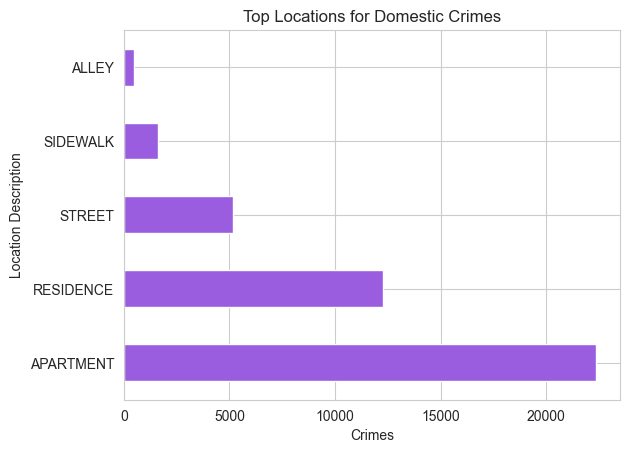

In [157]:

# domestic crime location 
crimes[crimes['Domestic']==True]['Location Description'].value_counts().head(5).plot(kind='barh', color='#9B5DE0')
plt.title("Top Locations for Domestic Crimes")
plt.xlabel("Crimes")
plt.show()

<h1 style="font-size:12px;"><strong>
Insight 31. Apartments are the leading setting for domestic crimes, with the highest incident count<strong>

<h1 style="font-size:12px;"><strong>
Insight 32. Residences rank second, reinforcing that domestic incidents mostly occur in private living spaces rather than public areas.<strong>



<h1 style="font-size:20px;"><strong>
CRIMES BY MONTH</h1>

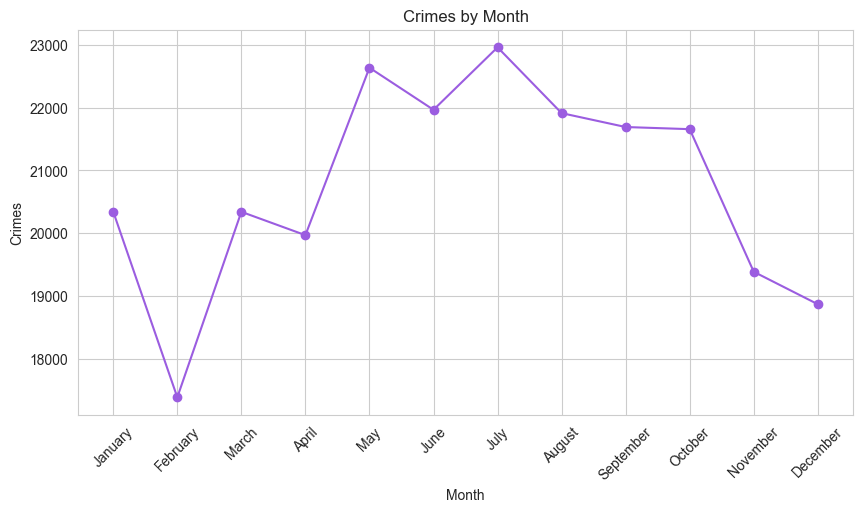

In [158]:
crimes['Month'] = pd.to_datetime(crimes['Date']).dt.month


crimes.groupby('Month').size().plot(kind='line', marker='o', color='#9B5DE0', figsize=(10, 5))
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Crimes")

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)

plt.grid(True)
plt.show()


<h1 style="font-size:12px;"><strong>
Insight 33. July records the highest number of crimes, while Febuary has the least number of crime<strong></h1>

<h3 style="font-size:12px;"><strong>
Insight 34. Crime levels remain relatively steady from August to October before dropping in November and December<strong></h3>


<h1 style="font-size:20px;"><strong>
TOP 5 CRIME TYPES IN CHICAGO OVER TIME</h1>

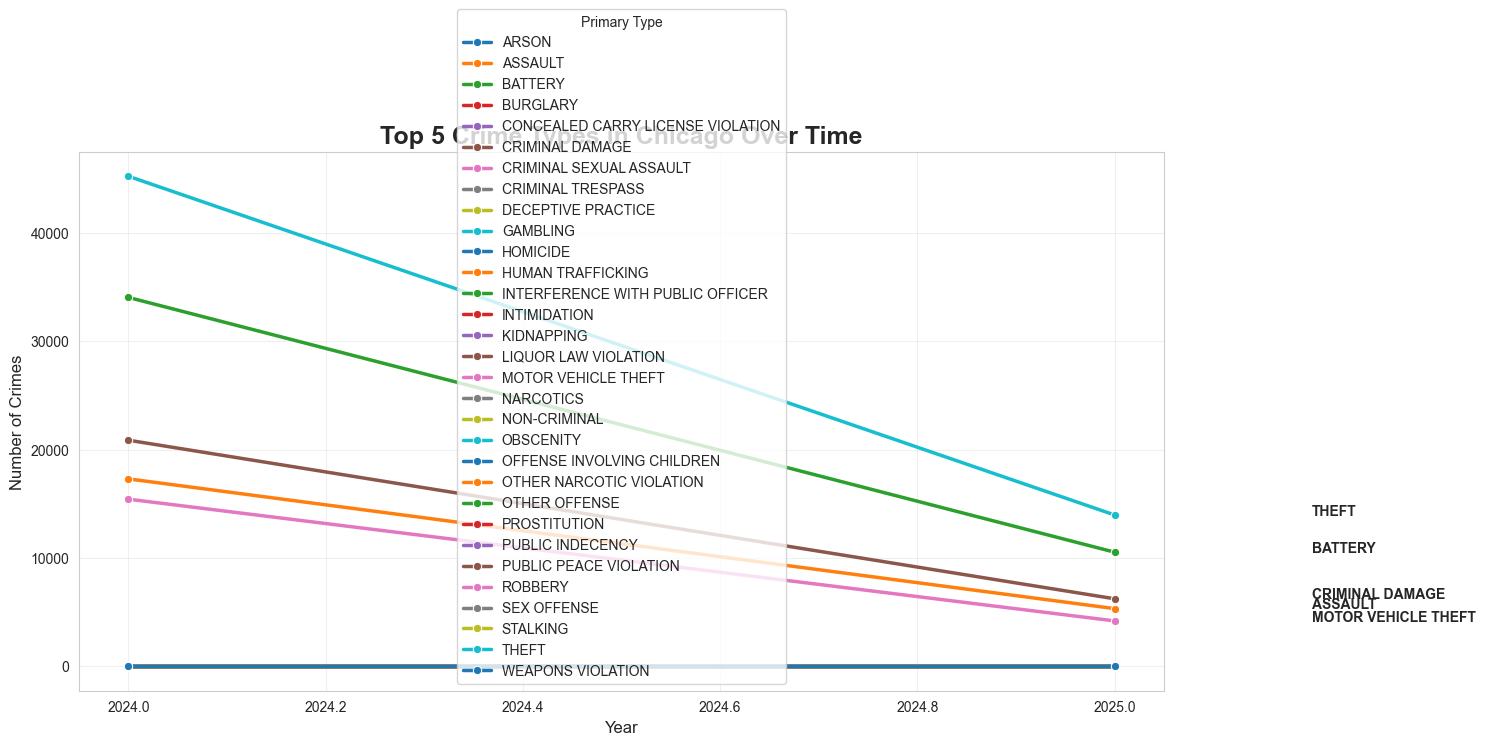

In [159]:

# Get top 5 crime categories
top_types = crimes['Primary Type'].value_counts().head(5).index
trend = crimes[crimes['Primary Type'].isin(top_types)]

# Group by year and type
trend_group = trend.groupby(['Year','Primary Type']).size().reset_index(name='Counts')

sns.set_style("whitegrid")
plt.figure(figsize=(14,7))


sns.lineplot(x='Year', y='Counts', hue='Primary Type', data=trend_group,
             marker='o', linewidth=2.5, palette="tab10")

# value for each line
for crime in top_types:
    last_point = trend_group[trend_group['Primary Type']==crime].iloc[-1]
    plt.text(last_point['Year']+0.2, last_point['Counts'], crime, fontsize=10, weight='bold')

plt.title("Top 5 Crime Types in Chicago Over Time", fontsize=18, weight='bold')
plt.ylabel("Number of Crimes", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(alpha=0.3)

plt.show()


<h1 style="font-size:12px;"><strong>
Insight 35.Theft is the most common crime type but shows a clear decline from 2024 to 2025.
Battery, assault, and criminal damage also exhibit decreasing trends during the same period.
This indicates an overall drop in the majority of top crime categories<strong></h1>




<h1 style="font-size:20px;"><strong>
CORRELATION MATRIX HIGLIGHTS</h1>

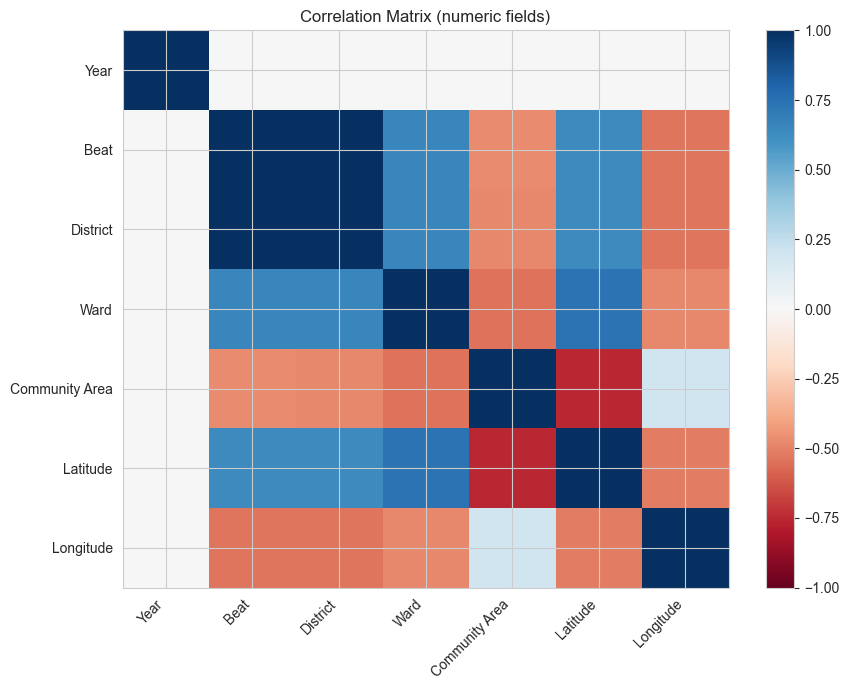

In [160]:
# 1) list of numeric columns
numeric_cols = [
    'Year',
    'ArrestFlag',
    'DomesticFlag',
    'Beat',
    'District',
    'Ward',
    'Community Area',
    'Latitude',
    'Longitude'
]


numeric_cols = [c for c in numeric_cols if c in crimes.columns]


corr = crimes[numeric_cols].corr()

plt.figure(figsize=(9,7))
im = plt.imshow(
    corr,
    interpolation='nearest',
    aspect='auto',
    cmap='RdBu',
    vmin=-1,
    vmax=1
)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix (numeric fields)')
plt.tight_layout()
plt.show()


<h1 style="font-size:12px;"><strong>
Insight 36. Beat, District, and Ward are strongly correlated, showing that these administrative zones overlap geographically.<strong></h1>

<h3 style="font-size:12px;"><strong>
Insight 37. Year has almost no correlation with other fields, suggesting that spatial patterns haven't changed much over time</strong></h3>



    

<h1 style="font-size:20px;"><strong>
GEOSPATIAL HOTSPOT</h1>

In [163]:
import folium
from folium.plugins import HeatMap


chicago_geo = crimes[['Latitude','Longitude']].dropna()

locations = list(zip(chicago_geo['Latitude'], chicago_geo['Longitude']))

m = folium.Map(location=[chicago_geo['Latitude'].mean(), chicago_geo['Longitude'].mean()], zoom_start=11)

HeatMap(locations).add_to(m)


m.save('chicago_crime_heatmap.html')
m



<h1 style="font-size:12px;"><strong>
Insight 38. The bright red areas downtown (Loop and Near North Side) shows the highest crime density<strong></h1>

<h2 style="font-size:12px;"><strong>
Insight 39. Orange clusters on the West and South Sides show that these place also experience high levels of crime<strong></h2>

<h3 style="font-size:12px;"><strong>
Insight 40.The green zones toward the North and outer edges of the map indicate much fewer crimes compared to the central zoney<strong></h3>
